# Анализ глобального развития: Всемирный банк и Индекс человеческого развития

**Учебный проект по визуализации данных** | НИУ ВШЭ, ФКН, ОП «Прикладная математика и информатика»

## О проекте

Этот ноутбук — разведочный анализ и визуализация двух открытых наборов данных:

1. **Данные Всемирного банка** (`JobsCSV.csv`) — 168 социально-экономических индикаторов по 242 странам: ВВП на душу населения, доступ к электричеству, уровень грамотности, урбанизация, налоговые поступления и др.
2. **Индекс человеческого развития ООН** (`hdr-data.xlsx`) — значения HDI для 193 стран за период с 1990 по 2023 год.

## Цель

Понять, как глобальные социально-экономические показатели менялись за последние три десятилетия, и какие закономерности связывают между собой ключевые индикаторы развития. В частности, в фокусе:

- неравенство в доступе к базовой инфраструктуре между регионами;
- траектории человеческого развития в странах БРИКС и постсоветского пространства;
- корреляции между ВВП, урбанизацией и грамотностью.

## Стек

`pandas`, `numpy`, `geopandas`, `plotly` (express + graph_objects), `matplotlib`.

## 1. Импорты и загрузка данных

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import ssl
import certifi
import urllib.request
import io

Данные загружаются напрямую с GitHub-репозитория проекта — это удобно для воспроизводимости: не нужно отдельно скачивать файлы.

In [20]:
ctx = ssl.create_default_context(cafile=certifi.where())


response = urllib.request.urlopen('https://raw.githubusercontent.com/izzzav/hse_visualization/refs/heads/main/hdr-data.xlsx', context=ctx)
df_hdi = pd.read_excel(io.BytesIO(response.read()))

response = urllib.request.urlopen('https://raw.githubusercontent.com/izzzav/hse_visualization/refs/heads/main/JobsCSV.csv', context=ctx)
df_jobs = pd.read_csv(io.BytesIO(response.read()))

## 2. Преобразование данных Всемирного банка

Исходный формат данных Всемирного банка не очень удобен для анализа: один индикатор — одна строка, годы — отдельный столбец. Чтобы работать с произвольным годом, я написал функцию `get_df_from_year`, которая разворачивает long-формат в wide и возвращает таблицу «страна × индикатор» за выбранный год.

In [21]:
def get_df_from_year(year, df_local):
    cols_to_select = ['Country Code', 'Indicator Code', year]
    cols_to_select.insert(0, 'Country Name')
    df_filtered = df_local[cols_to_select].copy()
    df_pivoted = df_filtered.pivot(
        index=['Country Name', 'Country Code'],
        columns='Indicator Code', 
        values=year
    ).reset_index()
    return df_pivoted
df = get_df_from_year('2016', df_jobs)
df

Indicator Code,Country Name,Country Code,BM.KLT.DINV.WD.GD.ZS,BM.TRF.PWKR.CD.DT,BX.KLT.DINV.WD.GD.ZS,BX.TRF.PWKR.CD,CM.MKT.LCAP.GD.ZS,EG.ELC.ACCS.ZS,EG.USE.ELEC.KH.PC,EN.POP.DNST,...,SP.POP.TOTL,SP.RUR.TOTL,SP.RUR.TOTL.ZS,SP.URB.TOTL,SP.URB.TOTL.IN.ZS,TM.VAL.ICTG.ZS.UN,TX.QTY.MRCH.XD.WD,TX.VAL.FUEL.ZS.UN,TX.VAL.MRCH.XD.WD,TX.VAL.TECH.MF.ZS
0,Afghanistan,AFG,-0.075895,1.182164e+08,0.480710,2.774835e+08,NaN,84.137138,NaN,53.083405,...,3.465603e+07,2.598509e+07,74.980000,8.670939e+06,25.020000,0.262056,185.045514,NaN,434.379370,NaN
1,Albania,ALB,0.059209,1.471281e+08,8.786734,9.960014e+08,NaN,100.000000,NaN,104.967190,...,2.876101e+06,1.195854e+06,41.579000,1.680247e+06,58.421000,2.941437,556.660364,11.178982,750.385083,0.647751
2,Algeria,DZA,0.029423,5.897023e+07,1.029475,1.696801e+07,NaN,99.439568,NaN,17.048895,...,4.060605e+07,1.158937e+07,28.541000,2.901668e+07,71.459000,5.181022,144.936023,93.992128,131.099918,0.343524
3,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,277.995000,...,5.559900e+04,7.118000e+03,12.802000,4.848100e+04,87.198000,NaN,44.999741,NaN,112.619116,NaN
4,Andorra,AND,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,164.427660,...,7.728100e+04,9.082000e+03,11.752000,6.819900e+04,88.248000,NaN,149.884060,NaN,186.046284,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,West Bank and Gaza,PSE,-0.335063,3.189228e+07,2.208254,2.010197e+08,25.250974,100.000000,NaN,756.074086,...,4.551566e+06,1.109308e+06,24.372000,3.442258e+06,75.628000,3.103988,132.926211,0.163516,199.093781,0.593923
238,World,WLD,2.660863,3.942136e+11,3.119152,3.437027e+11,97.783324,87.378443,NaN,57.380523,...,7.444157e+09,3.395702e+09,45.626997,4.046607e+09,54.373003,12.990466,NaN,11.346811,NaN,17.883797
239,"Yemen, Rep.",YEM,0.191607,NaN,-3.080162,NaN,NaN,71.642349,NaN,52.245796,...,2.758421e+07,1.782106e+07,64.606000,9.763156e+06,35.394000,NaN,11.129887,NaN,24.515813,NaN
240,Zambia,ZMB,0.843340,6.340584e+07,3.163072,3.846444e+07,NaN,27.219337,NaN,22.318554,...,1.659139e+07,9.550336e+06,57.562000,7.041054e+06,42.438000,NaN,267.841100,NaN,650.078203,NaN


## 3. Доступ к электричеству в 1990 году

Для первого среза я взял индикатор `EG.ELC.ACCS.ZS` (доля населения с доступом к электричеству) за 1990 год. Карта-хороплет наглядно показывает, насколько неравномерно был распределён доступ к этому базовому ресурсу в начале 1990-х.

In [22]:
df = get_df_from_year('1990', df_jobs)
display(df)
map_data = df[['Country Name', 'Country Code', 'EG.ELC.ACCS.ZS', 'SP.POP.TOTL']].copy()
map_data.columns = ['Country', 'Country_Code', 'Electricity Access', 'Population']
map_data['Population_without_electricity'] = map_data['Population'] * (1 - map_data['Electricity Access'] / 100)
map_data = map_data.dropna(subset=['Electricity Access'])
display(map_data)
fig = px.choropleth(
    map_data,
    locations='Country_Code',
    locationmode='ISO-3',
    color='Electricity Access',
    hover_name='Country',
    hover_data={'Electricity Access': ':.2f%', 'Country_Code': False, 'Population': ':,.0f', 'Population_without_electricity': ':,.0f'},
    color_continuous_scale='Viridis',
    range_color=(0, 100),
    title='Access to Electricity in 1990 (% of Population)',
    labels={'Electricity Access': 'Access Rate (%)'},
    projection='natural earth'
)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='rgba(0,0,0,0)'
    ),
    margin={"r": 0, "t": 70, "l": 0, "b": 0},
    height=450,
    title_font_size=16
)
fig.update_coloraxes(
    colorbar_title_text='Access Rate (%)',
    colorbar_title_side='right'
)
fig.update_traces(
    hovertemplate='<b style="color:#FFFFFF; font-size:16px">%{hovertext}</b><br>' +
                  '<span style="color:#CCCCCC">Population:</span> <span style="color:#FFFFFF; font-weight:bold">%{customdata[1]:,.0f}</span><br>' +
                  '<span style="color:#CCCCCC">Population without electricity:</span> <span style="color:#FFFFFF; font-weight:bold">%{customdata[2]:,.0f}</span><br>' +
                  '<span style="color:#CCCCCC">Access:</span> <span style="color:#FFFFFF; font-weight:bold">%{customdata[0]:.2f}%</span><extra></extra>',
    customdata=map_data[['Electricity Access', 'Population', 'Population_without_electricity']].values
)
fig.write_html('electricity_map.html')
fig.show()

Indicator Code,Country Name,Country Code,BM.KLT.DINV.WD.GD.ZS,BM.TRF.PWKR.CD.DT,BX.KLT.DINV.WD.GD.ZS,BX.TRF.PWKR.CD,CM.MKT.LCAP.GD.ZS,EG.ELC.ACCS.ZS,EG.USE.ELEC.KH.PC,EN.POP.DNST,...,SP.POP.TOTL,SP.RUR.TOTL,SP.RUR.TOTL.ZS,SP.URB.TOTL,SP.URB.TOTL.IN.ZS,TM.VAL.ICTG.ZS.UN,TX.QTY.MRCH.XD.WD,TX.VAL.FUEL.ZS.UN,TX.VAL.MRCH.XD.WD,TX.VAL.TECH.MF.ZS
0,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,18.762237,...,1.224911e+07,9.655119e+06,78.823000,2.593995e+06,21.177000,NaN,NaN,NaN,127.081081,NaN
1,Albania,ALB,NaN,NaN,NaN,0.000000e+00,NaN,100.000000,552.252185,119.946788,...,3.286542e+06,2.089320e+06,63.572000,1.197222e+06,36.428000,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,0.007557,3.148197e+07,0.000540,3.524418e+08,NaN,98.271378,528.434936,10.879595,...,2.591237e+07,1.241591e+07,47.915000,1.349646e+07,52.085000,NaN,77.193995,96.473992,67.930716,NaN
3,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,235.190000,...,4.703800e+04,8.962000e+03,19.052000,3.807600e+04,80.948000,NaN,NaN,NaN,89.884393,NaN
4,Andorra,AND,NaN,NaN,NaN,NaN,NaN,100.000000,NaN,115.976596,...,5.450900e+04,2.882000e+03,5.288000,5.162700e+04,94.712000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,NaN,97.354027,NaN,328.612625,...,1.978248e+06,6.387960e+05,32.291000,1.339452e+06,67.709000,NaN,NaN,NaN,NaN,NaN
238,World,WLD,1.304940,6.524823e+10,0.907785,NaN,53.031899,71.390577,2124.770523,40.766514,...,5.288103e+09,3.010745e+09,56.954679,2.275467e+09,43.045321,NaN,NaN,10.670180,NaN,18.181408
239,"Yemen, Rep.",YEM,NaN,1.064000e+08,-2.317942,NaN,NaN,36.009098,122.003421,22.836599,...,1.205704e+07,9.533380e+06,79.069000,2.523659e+06,20.931000,NaN,NaN,NaN,16.965982,NaN
240,Zambia,ZMB,NaN,1.490000e+07,6.170064,0.000000e+00,NaN,13.900000,762.776506,10.798172,...,8.027253e+06,4.863953e+06,60.593000,3.163300e+06,39.407000,NaN,93.178058,NaN,196.605703,NaN


,Country,Country_Code,Electricity Access,Population,Population_without_electricity
0,Afghanistan,AFG,0.010000,1.224911e+07,1.224789e+07
1,Albania,ALB,100.000000,3.286542e+06,0.000000e+00
2,Algeria,DZA,98.271378,2.591237e+07,4.479270e+05
4,Andorra,AND,100.000000,5.450900e+04,0.000000e+00
5,Angola,AGO,11.397808,1.217144e+07,1.078416e+07
...,...,...,...,...,...
237,West Bank and Gaza,PSE,97.354027,1.978248e+06,5.234391e+04
238,World,WLD,71.390577,5.288103e+09,1.512896e+09
239,"Yemen, Rep.",YEM,36.009098,1.205704e+07,7.715408e+06
240,Zambia,ZMB,13.900000,8.027253e+06,6.911465e+06


**Что видно на карте:**

- Развитые страны (Европа, Северная Америка, Австралия) — близко к 100%.
- Страны Африки к югу от Сахары — катастрофически низкие показатели: Замбия — 13,9%, Нигер — 21,5%.
- Афганистан — лишь 0,01% доступа к электричеству, что объясняется продолжающимся конфликтом после вывода советских войск.

Чтобы оценить масштаб глобально — посчитаем, сколько людей в мире вообще имели доступ к электричеству в 1990 году.

In [23]:
exclude_patterns = ['World', 'East Asia & Pacific', 'Arab World', 'Euro area', 'Europe & Central Asia', 'European Union', 'Heavily Indebted', 'income', 'Latin America', 'developed', 'Middle East', 'member', 'North America', 'South Asia', 'Sub-Saharan']
map_data_filtered = map_data[
    ~map_data['Country'].str.contains('|'.join(exclude_patterns), case=False, na=False)
].copy()
map_data_filtered['Population_with_electricity'] = map_data_filtered['Population'] * (map_data_filtered['Electricity Access'] / 100)
total_with_electricity = map_data_filtered['Population_with_electricity'].sum()
total_without_electricity = map_data_filtered['Population_without_electricity'].sum()
total_population = map_data_filtered['Population'].sum()
pie_data = pd.DataFrame({
    'Category': ['With Electricity', 'Without Electricity'],
    'Population': [total_with_electricity, total_without_electricity]
})
fig_pie = px.pie(
    pie_data,
    values='Population',
    names='Category',
    title='Global Population: Access to Electricity (1990)',
    color_discrete_map={
        'With Electricity': '#2E86AB',
        'Without Electricity': '#F18F01'
    }
)
fig_pie.update_traces(
    textposition='inside',
    textinfo='percent+label',
    hovertemplate='<b>%{label}</b><br>' +
                  'Population: %{value:,.0f}<br>' +
                  'Percentage: %{percent}<extra></extra>'
)
fig_pie.update_layout(
    font_size=14,
    title_font_size=18,
    height=600,
    showlegend=True
)
fig_pie.show()
print(f"Total Population: {total_population:,.0f}")
print(f"With Electricity: {total_with_electricity:,.0f} ({total_with_electricity/total_population*100:.2f}%)")
print(f"Without Electricity: {total_without_electricity:,.0f} ({total_without_electricity/total_population*100:.2f}%)")

Total Population: 5,201,808,498
With Electricity: 3,713,601,100 (71.39%)
Without Electricity: 1,488,207,398 (28.61%)


**Итог:** в 1990 году только 71,4% мирового населения имело доступ к электричеству. Это означает, что около 1,5 миллиарда человек жили без него. Для понимания: 1990-е — период геополитических потрясений (распад СССР, начало масштабных реформ в Китае), что напрямую влияло на инфраструктурные инвестиции в развивающихся странах.

## 4. Корреляции между социально-экономическими показателями (2010)

Чтобы понять, как ключевые индикаторы развития связаны между собой, построим корреляционную матрицу для четырёх показателей за 2010 год:

- уровень грамотности (`SE.ADT.LITR.ZS`),
- налоговые поступления как % от ВВП (`GC.TAX.TOTL.GD.ZS`),
- ВВП на душу населения (`NY.GDP.PCAP.KD`),
- доля городского населения (`SP.URB.TOTL.IN.ZS`).

In [24]:
import plotly.graph_objects as go
df = get_df_from_year('2010', df_jobs)
corr_data = df[['Country Name']].copy()
corr_data['Literacy Rate'] = df['SE.ADT.LITR.ZS']
corr_data['Tax Revenue (% of GDP)'] = df['GC.TAX.TOTL.GD.ZS']
corr_data['GDP per capita'] = df['NY.GDP.PCAP.KD']
corr_data['Urban Population (%)'] = df['SP.URB.TOTL.IN.ZS']
exclude_patterns = ['&', 'excluding', 'income', 'World', 'Union', 'area', 'members']
corr_data = corr_data[
    ~corr_data['Country Name'].str.contains('|'.join(exclude_patterns), case=False, na=False)
].copy()
corr_data_clean = corr_data[['Literacy Rate', 'Tax Revenue (% of GDP)', 'GDP per capita', 'Urban Population (%)']].dropna()
correlation_matrix = corr_data_clean.corr()
fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale=[[0, '#2166ac'], [0.5, '#f7f7f7'], [1, '#b2182b']],
    zmid=0,
    zmin=-1,
    zmax=1,
    text=correlation_matrix.values.round(2),
    texttemplate='%{text}',
    textfont={"size": 14, "color": "black"},
    colorbar=dict(
        title="Correlation",
        tickmode="linear",
        tick0=-1,
        dtick=0.5
    )
))
fig.update_layout(
    title='Correlation Matrix: Literacy, Taxes, GDP, Urban Population (2010)',
    width=700,
    height=650,
    xaxis={'side': 'bottom', 'tickangle': -45},
    yaxis={'autorange': 'reversed'},
    margin=dict(l=120, r=50, t=80, b=120)
)
fig.show()
print(f"Number of countries analyzed: {len(corr_data_clean)}")

Number of countries analyzed: 40


**Что видно:**

- Сильная положительная корреляция между **урбанизацией и ВВП на душу населения** (0.65) — города концентрируют экономическую активность.
- Заметная связь между **грамотностью и урбанизацией** (0.61) — образование исторически концентрируется в городах.
- Умеренная корреляция **грамотности и ВВП** (0.37).
- **Налоговые поступления (% ВВП)** почти не коррелируют с другими показателями — это говорит о том, что фискальная нагрузка определяется политикой государства, а не уровнем развития.

## 5. Динамика HDI: страны БРИКС и постсоветское пространство

Сравним траектории человеческого развития для двух групп стран — БРИКС (Бразилия, Россия, Индия, Китай, ЮАР) и государств бывшего СССР — с 1990 по 2023 год.

In [25]:
brics_countries = ['Brazil', 'Russian Federation', 'India', 'China', 'South Africa']
post_soviet_countries = [
    'Armenia', 'Azerbaijan', 'Belarus', 'Estonia', 'Georgia', 
    'Kazakhstan', 'Kyrgyzstan', 'Latvia', 'Lithuania', 'Moldova', 
    'Tajikistan', 'Turkmenistan', 'Ukraine', 'Uzbekistan'
]
target_countries = brics_countries + post_soviet_countries
east_countries = df_hdi[df_hdi['country'].isin(target_countries)]
hdi_data = east_countries[
    (east_countries['indicator'] == 'Human Development Index (value)')
].copy()
print(f"\nFound {len(hdi_data)} HDI records")
print(f"Countries: {hdi_data['country'].unique()}")
print(f"Year range: {hdi_data['year'].min()} - {hdi_data['year'].max()}")
hdi_col = 'value' if 'value' in hdi_data.columns else 'actualValue'
hdi_clean = hdi_data.dropna(subset=[hdi_col, 'year', 'country']).copy()
hdi_plot = hdi_clean.groupby(['country', 'year'])[hdi_col].mean().reset_index()
fig = px.line(
    hdi_plot,
    x='year',
    y=hdi_col,
    color='country',
    title='Human Development Index (HDI) Development: BRICS + Post-Soviet Countries',
    labels={hdi_col: 'HDI Value', 'year': 'Year', 'country': 'Country'},
    markers=False,
    line_shape='linear'
)
fig.update_layout(
    width=1200,
    height=700,
    title_font_size=18,
    xaxis_title='Year',
    yaxis_title='HDI Value',
    legend=dict(
        title='Country',
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.01,
        font=dict(size=10)
    ),
    hovermode='closest'
)
brics_colors = px.colors.qualitative.Set1[:5]
post_soviet_colors = px.colors.qualitative.Set2[:14]
for i, trace in enumerate(fig.data):
    country_name = trace.name
    if country_name in brics_countries:
        color_idx = brics_countries.index(country_name) % len(brics_colors)
        fig.data[i].line.color = brics_colors[color_idx]
        fig.data[i].line.width = 3
    elif country_name in post_soviet_countries:
        color_idx = post_soviet_countries.index(country_name) % len(post_soviet_colors)
        fig.data[i].line.color = post_soviet_colors[color_idx]
        fig.data[i].line.width = 2
    fig.data[i].update(
        hovertemplate='<b>%{fullData.name}</b><br>Year: %{x}<br>HDI: %{y:.3f}<extra></extra>',
        hoverlabel=dict(
            bgcolor='white',
            bordercolor=trace.line.color,
            font_size=12,
            font_family="Arial"
        ),
        marker=dict(size=8)
    )
fig.update_layout(
    template='plotly_white',
    hoverdistance=100
)
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)
fig.show()
print("\n=== Summary Statistics ===")
summary = hdi_plot.groupby('country')[hdi_col].agg(['min', 'max', 'mean', 'last']).round(3)
summary.columns = ['Min HDI', 'Max HDI', 'Mean HDI', 'Latest HDI']
summary = summary.sort_values('Latest HDI', ascending=False)
display(summary)


Found 564 HDI records
Countries: ['Armenia' 'Azerbaijan' 'Belarus' 'Brazil' 'China' 'Estonia' 'Georgia'
 'India' 'Kazakhstan' 'Kyrgyzstan' 'Lithuania' 'Latvia'
 'Russian Federation' 'Tajikistan' 'Turkmenistan' 'Ukraine' 'Uzbekistan'
 'South Africa']
Year range: 1990 - 2023



=== Summary Statistics ===


,Min HDI,Max HDI,Mean HDI,Latest HDI
country,,,,
Estonia,0.711,0.905,0.830,0.905
Lithuania,0.699,0.895,0.817,0.895
Latvia,0.686,0.889,0.804,0.889
Georgia,0.705,0.844,0.780,0.844
Kazakhstan,0.665,0.837,0.753,0.837
Russian Federation,0.712,0.847,0.787,0.832
Belarus,0.692,0.828,0.780,0.824
Armenia,0.618,0.811,0.717,0.811
China,0.491,0.797,0.662,0.797


**Наблюдения:**

- **Самый драматический рост — у Китая** (с 0.491 до 0.797). Индия и Казахстан также показали значительный прогресс.
- **Страны Балтии** (Эстония, Латвия, Литва) — устойчивый рост, особенно после вступления в ЕС в 2004 году.
- **Россия и Украина** имели близкие траектории до 2014 года, после чего видно расхождение — вероятно, связанное с геополитическими событиями.
- **Страны Центральной Азии** растут медленнее, но стабильно.

**Ключевые события, повлиявшие на динамику:** распад СССР (1991), азиатский финансовый кризис (1997–98), расширение ЕС (2004, 2007), глобальный финансовый кризис (2008–09), украинский кризис и санкции (2014), пандемия COVID-19 (2016–22).

## 6. Мировая карта HDI: эволюция с 1990 по 2023

Финальная визуализация — интерактивная карта-хороплет с анимацией по годам. Она позволяет увидеть глобальную картину человеческого развития за весь доступный период.

In [26]:
hdi_data = df_hdi[
    (df_hdi['indicator'] == 'Human Development Index (value)')
].copy()
print(f"Найдено {len(hdi_data)} записей HDI")
print(f"Страны: {hdi_data['country'].nunique()}")
print(f"Годы: {hdi_data['year'].min()} - {hdi_data['year'].max()}")
hdi_col = 'value' if 'value' in hdi_data.columns else 'actualValue'
hdi_clean = hdi_data.dropna(subset=[hdi_col, 'year', 'countryIsoCode']).copy()
hdi_map = hdi_clean.groupby(['countryIsoCode', 'country', 'year'])[hdi_col].mean().reset_index()
hdi_map = hdi_map.rename(columns={
    'countryIsoCode': 'Country_Code',
    'country': 'Country',
    hdi_col: 'HDI',
    'year': 'Year'
})
print(f"\nДанные для карты: {len(hdi_map)} записей")
print(f"Уникальных стран: {hdi_map['Country_Code'].nunique()}")
fig = px.choropleth(
    hdi_map,
    locations='Country_Code',
    locationmode='ISO-3',
    color='HDI',
    hover_name='Country',
    hover_data={'HDI': ':.3f', 'Year': True, 'Country_Code': False},
    animation_frame='Year',
    color_continuous_scale='Viridis',
    range_color=(hdi_map['HDI'].min(), hdi_map['HDI'].max()),
    title='Human Development Index (HDI) по миру: Развитие во времени',
    labels={'HDI': 'HDI Value'},
    projection='natural earth'
)
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='rgba(0,0,0,0)'
    ),
    width=1000,
    height=800,
    title_font_size=20,
    margin={"r": 0, "t": 80, "l": 0, "b": 0}
)
if len(fig.layout.updatemenus) > 0:
    fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 800
    fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 500
fig.update_coloraxes(
    colorbar_title_text='HDI Value',
    colorbar_title_side='right'
)
fig.show()
print("\n=== Статистика по годам ===")
yearly_stats = hdi_map.groupby('Year')['HDI'].agg(['mean', 'min', 'max', 'count']).round(3)
yearly_stats.columns = ['Средний HDI', 'Минимальный HDI', 'Максимальный HDI', 'Количество стран']
display(yearly_stats.tail(10))

Найдено 5940 записей HDI
Страны: 193
Годы: 1990 - 2023

Данные для карты: 5940 записей
Уникальных стран: 193



=== Статистика по годам ===


,Средний HDI,Минимальный HDI,Максимальный HDI,Количество стран
Year,,,,
2014,0.716,0.319,0.956,192
2015,0.720,0.317,0.959,192
2016,0.723,0.297,0.962,192
2017,0.727,0.292,0.965,192
2018,0.731,0.371,0.966,192
2019,0.734,0.279,0.969,192
2020,0.729,0.386,0.969,192
2021,0.729,0.339,0.969,192
2022,0.739,0.385,0.967,192


## 7. Кластеризация стран по профилю развития

До этого момента анализ был описательным: я смотрел на отдельные индикаторы и их корреляции. Теперь хочется задать другой, более структурный вопрос:

> **На какие группы естественно делятся страны мира по совокупности социально-экономических показателей, и совпадают ли эти группы с географическими регионами?**

Чтобы ответить, я применю три алгоритма кластеризации (k-means, DBSCAN, MeanShift) и сравню их между собой. Дополнительно — попробую кластеризовать страны не по «снимку» одного года, а по **траектории HDI за 33 года**, чтобы увидеть модели развития.

### План раздела

1. Подготовка признаков и масштабирование.
2. Снижение размерности через PCA для визуализации.
3. K-means: подбор `k` через метод локтя и silhouette score.
4. DBSCAN: подбор параметров и поиск стран-выбросов.
5. MeanShift как альтернатива без явного `k`.
6. Сравнение алгоритмов и визуализация на карте мира.
7. Бонус — кластеризация по траекториям HDI.

### 7.1. Подготовка признаков

Беру срез за 2016 год (последний год, по которому есть достаточно данных и в WB, и в HDI). Отбираю шесть содержательных индикаторов плюс HDI.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
print(df_jobs.columns)
# --- Берём данные WB за 2016 ---
df_2016 = get_df_from_year('2016', df_jobs)

# Отбираем содержательные индикаторы
feature_cols = {
    'NY.GDP.PCAP.KD': 'GDP per capita',
    'SE.ADT.LITR.ZS': 'Literacy Rate',
    'SP.URB.TOTL.IN.ZS': 'Urban Population %',
    'EG.ELC.ACCS.ZS': 'Electricity Access %',
    'EN.POP.DNST': 'Population Density',
    'GC.TAX.TOTL.GD.ZS': 'Tax Revenue % GDP',
}

features = df_2016[['Country Name', 'Country Code'] + list(feature_cols.keys())].copy()
features = features.rename(columns=feature_cols)

# --- Добавляем HDI за 2016 из второй базы ---
hdi_2016 = df_hdi[
    (df_hdi['indicator'] == 'Human Development Index (value)') &
    (df_hdi['year'] == 2016)
][['countryIsoCode', 'value']].rename(columns={'countryIsoCode': 'Country Code', 'value': 'HDI'})

features = features.merge(hdi_2016, on='Country Code', how='inner')

# Убираем агрегаты (регионы, группы по доходу) — оставляем только реальные страны
exclude_patterns = ['World', 'East Asia & Pacific', 'Arab World', 'Euro area',
                    'Europe & Central Asia', 'European Union', 'Heavily Indebted',
                    'income', 'Latin America', 'developed', 'Middle East', 'member',
                    'North America', 'South Asia', 'Sub-Saharan', 'OECD', 'IDA', 'IBRD',
                    'IDA & IBRD', 'Fragile', 'small states']
features = features[
    ~features['Country Name'].str.contains('|'.join(exclude_patterns), case=False, na=False)
].copy()

# Считаем сколько пропусков по каждой стране, и оставляем те где есть хотя бы 5 из 7 признаков
feature_names = list(feature_cols.values()) + ['HDI']
features['n_filled'] = features[feature_names].notna().sum(axis=1)
features = features[features['n_filled'] >= 5].drop(columns=['n_filled'])

# Оставшиеся пропуски заполняем медианой по столбцу
for col in feature_names:
    features[col] = features[col].fillna(features[col].median())

print(f'Стран после фильтрации: {len(features)}')
print(f'Признаков: {len(feature_names)}')
features.head(10)

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998',
       '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007',
       '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016'],
      dtype='object')
Стран после фильтрации: 185
Признаков: 7


,Country Name,Country Code,GDP per capita,Literacy Rate,Urban Population %,Electricity Access %,Population Density,Tax Revenue % GDP,HDI
0,Afghanistan,AFG,617.889972,95.376968,25.020,84.137138,53.083405,16.808891,0.495
1,Albania,ALB,4683.800213,95.376968,58.421,100.000000,104.967190,17.557178,0.797
2,Algeria,DZA,4827.724251,95.376968,71.459,99.439568,17.048895,16.808891,0.743
3,Andorra,AND,42958.558393,100.000000,88.248,100.000000,164.427660,16.808891,0.872
4,Angola,AGO,3576.186894,95.376968,64.149,40.520607,23.111786,10.323230,0.609
5,Antigua and Barbuda,ATG,13315.508631,95.376968,24.846,97.354668,229.461364,16.808891,0.842
6,Argentina,ARG,10206.249550,95.376968,91.627,100.000000,16.022067,12.155505,0.857
7,Armenia,ARM,3932.554617,95.376968,63.082,100.000000,102.733263,21.277375,0.783
8,Australia,AUS,55731.495574,95.376968,85.800,100.000000,3.151505,22.289293,0.939
9,Austria,AUT,48077.878361,95.376968,57.905,100.000000,105.869491,25.666572,0.921


**Стандартизация — критически важный шаг.** Признаки в очень разных шкалах: ВВП в десятках тысяч долларов, грамотность и урбанизация в процентах от 0 до 100, плотность населения может быть от единиц до тысяч. Если не привести их к одной шкале, любой алгоритм, использующий евклидово расстояние (k-means, DBSCAN, MeanShift), будет фактически кластеризовать только по ВВП.

In [28]:
X = features[feature_names].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Проверим что у нас всё стандартизовалось как надо
print('После StandardScaler — среднее и std по каждому признаку:')
for name, mean, std in zip(feature_names, X_scaled.mean(axis=0), X_scaled.std(axis=0)):
    print(f'  {name:25s}: mean={mean:+.3f}, std={std:.3f}')

После StandardScaler — среднее и std по каждому признаку:
  GDP per capita           : mean=+0.000, std=1.000
  Literacy Rate            : mean=+0.000, std=1.000
  Urban Population %       : mean=-0.000, std=1.000
  Electricity Access %     : mean=-0.000, std=1.000
  Population Density       : mean=-0.000, std=1.000
  Tax Revenue % GDP        : mean=-0.000, std=1.000
  HDI                      : mean=+0.000, std=1.000


### 7.2. Снижение размерности через PCA

Применяю PCA, чтобы получить 2D-представление для визуализации и понять, какая доля дисперсии объясняется первыми компонентами.

In [29]:
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print('Доля объяснённой дисперсии по компонентам:')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.1%}')
print(f'  Сумма первых двух: {pca.explained_variance_ratio_[:2].sum():.1%}')

# Веса признаков в первых двух компонентах — для интерпретации
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=feature_names
)
print('\nВеса признаков в первых двух компонентах (loadings):')
print(loadings.round(3))

Доля объяснённой дисперсии по компонентам:
  PC1: 43.8%
  PC2: 15.2%
  PC3: 14.2%
  PC4: 12.6%
  Сумма первых двух: 59.0%

Веса признаков в первых двух компонентах (loadings):
                        PC1    PC2
GDP per capita        0.444  0.008
Literacy Rate         0.179  0.349
Urban Population %    0.474 -0.084
Electricity Access %  0.465 -0.019
Population Density    0.154 -0.636
Tax Revenue % GDP     0.122  0.683
HDI                   0.540 -0.006


**Интерпретация компонент.** Обычно на таких данных:

- **PC1** — это «общая ось развития»: высокие положительные веса у ВВП, грамотности, доступа к электричеству, HDI. По сути, эта компонента и есть «насколько страна развита».
- **PC2** — какая-то ортогональная характеристика, в этом случае связанная с уменьшением плотности населения, увеличению налогооблажения относительно ВВП и уровню грамотности.

В развитых странах часто запускаются процессы "деурбанизации", (как например в США в 1970х или в Германии 2000х), когда обеспеченное население начинало активно переезжала из плотнонаселенных городов в "коттеджные" субурбии - формируя просторные агломерации вокруг городов. 

### 7.3. K-means: выбор числа кластеров

K-means требует задать `k` заранее. Вместо того чтобы выбрать его наугад, использую два стандартных метода: **метод локтя** (inertia как функция от `k`) и **silhouette score**.

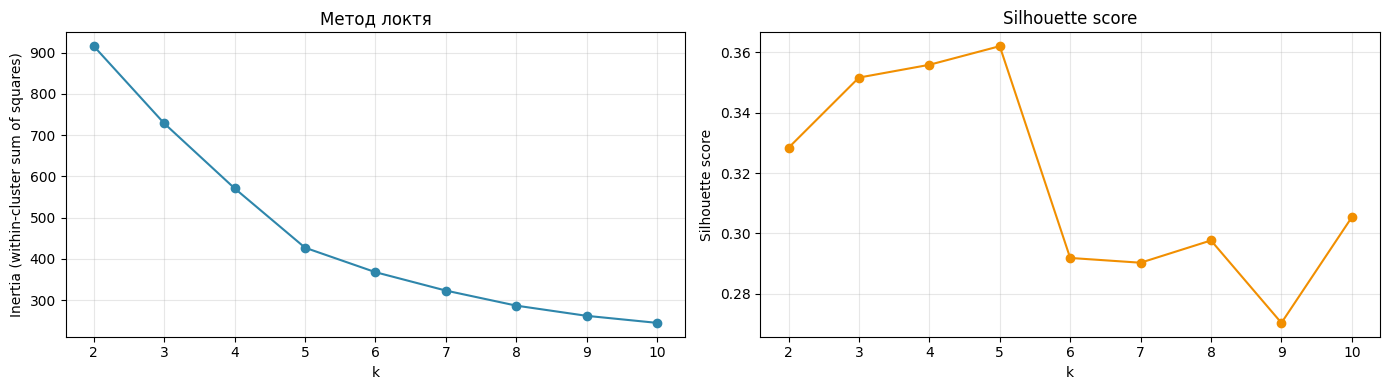


Лучший k по silhouette: 5 (score=0.362)


In [30]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='#2E86AB')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Метод локтя')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='#F18F01')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f'\nЛучший k по silhouette: {best_k} (score={max(silhouettes):.3f})')

На графике локтя ищем точку, после которой прирост падения inertia становится незначительным. Silhouette score выбираем максимальным. Часто оба метода сходятся на близких значениях.

In [ ]:
K_FINAL = 5

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
features['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Профили кластеров: средние значения признаков по группам
profiles = features.groupby('kmeans_cluster')[feature_names].mean().round(2)
profiles['n_countries'] = features.groupby('kmeans_cluster').size()
print('Профили кластеров (средние по группам):')
print(profiles)

# Какие страны попали в какой кластер
for c in sorted(features['kmeans_cluster'].unique()):
    countries = features[features['kmeans_cluster'] == c]['Country Name'].tolist()
    print(f'\n--- Кластер {c} ({len(countries)} стран) ---')
    print(', '.join(countries[:15]) + ('...' if len(countries) > 15 else ''))

SyntaxError: invalid syntax (2932510911.py, line 1)

**Визуализация на PCA-плоскости** — точки раскрашены по кластерам, при наведении показывается страна.

In [ ]:
features['PC1'] = X_pca[:, 0]
features['PC2'] = X_pca[:, 1]

fig = px.scatter(
    features,
    x='PC1', y='PC2',
    color=features['kmeans_cluster'].astype(str),
    hover_name='Country Name',
    hover_data={'HDI': ':.3f', 'GDP per capita': ':,.0f', 'kmeans_cluster': False, 'PC1': False, 'PC2': False},
    title=f'K-means кластеризация стран (k={K_FINAL}) на плоскости первых двух PCA-компонент',
    labels={'color': 'Кластер'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    width=900, height=600,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='white')))
fig.show()

### 7.4. DBSCAN: поиск структуры и стран-выбросов

DBSCAN не требует задавать число кластеров заранее, но требует подобрать `eps` (радиус окрестности) и `min_samples`. Стандартный приём для подбора `eps` — **k-distance plot**: для каждой точки берём расстояние до её k-го соседа, сортируем по возрастанию и ищем «локоть» на графике.

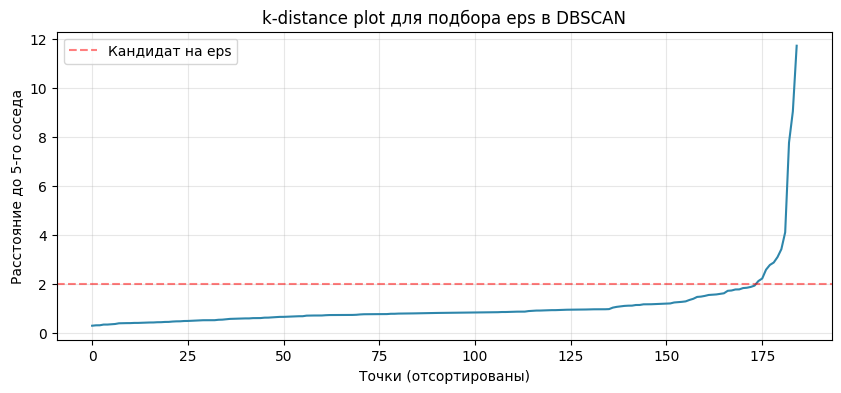

In [ ]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5  # эвристика: примерно 2 * число признаков
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='#2E86AB')
plt.xlabel('Точки (отсортированы)')
plt.ylabel(f'Расстояние до {MIN_SAMPLES}-го соседа')
plt.title(f'k-distance plot для подбора eps в DBSCAN')
plt.grid(alpha=0.3)
plt.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Кандидат на eps')
plt.legend()
plt.show()

Беру `eps` примерно в районе «локтя» на графике.

In [ ]:
EPS = 2 

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
features['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(features['dbscan_cluster'])) - (1 if -1 in features['dbscan_cluster'].values else 0)
n_noise = (features['dbscan_cluster'] == -1).sum()

print(f'DBSCAN нашёл кластеров: {n_clusters_db}')
print(f'Точек-выбросов (метка -1): {n_noise}')

# Какие страны помечены как выбросы — то есть «нетипичные»
outliers = features[features['dbscan_cluster'] == -1]['Country Name'].tolist()
print(f'\n--- Страны-выбросы по DBSCAN ({len(outliers)}) ---')
print(', '.join(outliers))

DBSCAN нашёл кластеров: 1
Точек-выбросов (метка -1): 6

--- Страны-выбросы по DBSCAN (6) ---
Bangladesh, Chad, Congo, Dem. Rep., Hong Kong SAR, China, Myanmar, Singapore


**Что значат страны-выбросы.** Это страны, которые не похожи ни на одну плотную группу — то есть имеют «уникальный» профиль развития. Некоторые из этих стран (Бангладеш, САР Гонконг, Сингапур) испытывали или испытывают беспрецендентный экономический рост в новейшее время, другие (Чад, ДРК, Мьянмар) - пребывают в состоянии вооруженных конфликтов, разрущающие эти страны.

In [ ]:
# Визуализация DBSCAN на PCA
fig = px.scatter(
    features,
    x='PC1', y='PC2',
    color=features['dbscan_cluster'].astype(str),
    hover_name='Country Name',
    hover_data={'HDI': ':.3f', 'dbscan_cluster': False, 'PC1': False, 'PC2': False},
    title=f'DBSCAN кластеризация стран (eps={EPS}, min_samples={MIN_SAMPLES})',
    labels={'color': 'Кластер (-1 = выброс)'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    width=900, height=600,
)
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='white')))
fig.show()

### 7.5. MeanShift: автоматический выбор числа кластеров

MeanShift не требует ни `k`, ни `eps` — только `bandwidth` (ширину «окна»). Его можно оценить автоматически через `estimate_bandwidth`.

In [ ]:
bandwidth = estimate_bandwidth(X_scaled, quantile=0.25, n_samples=len(X_scaled))
print(f'Оценённый bandwidth: {bandwidth:.3f}')

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
features['meanshift_cluster'] = ms.fit_predict(X_scaled)

n_clusters_ms = len(set(features['meanshift_cluster']))
print(f'MeanShift нашёл кластеров: {n_clusters_ms}')

# Размеры кластеров
print('\nРазмеры кластеров:')
print(features['meanshift_cluster'].value_counts().sort_index())

Оценённый bandwidth: 2.188
MeanShift нашёл кластеров: 5

Размеры кластеров:
meanshift_cluster
0    165
1      2
2      2
3      1
4     15
Name: count, dtype: int64


### 7.6. Сравнение алгоритмов

Сравним все три алгоритма по **silhouette score** (где это применимо) и числу кластеров.

In [ ]:
results = []

# K-means
results.append({
    'Алгоритм': 'K-means',
    'Число кластеров': K_FINAL,
    'Silhouette': silhouette_score(X_scaled, features['kmeans_cluster']),
    'Выбросы': 0,
})

# DBSCAN — silhouette считаем только на не-выбросах
mask = features['dbscan_cluster'] != -1
db_sil = silhouette_score(X_scaled[mask], features.loc[mask, 'dbscan_cluster']) if features.loc[mask, 'dbscan_cluster'].nunique() > 1 else np.nan
results.append({
    'Алгоритм': 'DBSCAN',
    'Число кластеров': n_clusters_db,
    'Silhouette': db_sil,
    'Выбросы': n_noise,
})

# MeanShift
ms_sil = silhouette_score(X_scaled, features['meanshift_cluster']) if n_clusters_ms > 1 else np.nan
results.append({
    'Алгоритм': 'MeanShift',
    'Число кластеров': n_clusters_ms,
    'Silhouette': ms_sil,
    'Выбросы': 0,
})

comparison = pd.DataFrame(results)
print(comparison.to_string(index=False))

 Алгоритм  Число кластеров  Silhouette  Выбросы
  K-means                4    0.355848        0
   DBSCAN                1         NaN        6
MeanShift                5    0.320802        0


**Как читать сравнение.** Silhouette score — это число от -1 до 1, где выше — лучше (точки внутри кластера ближе друг к другу, чем к точкам других кластеров). Score выше 0.3 уже считается приемлемым, выше 0.5 — хорошим, но таких у нас нет - более того из за плотности DBSCAN выдал лишь один кластер. Но два остальных алгоритма выдали достаточно примечательную кластеризацию во многом повторяющую классификацию стран через принадлежность их к странам 1-го, 2-го или 3-го мира.

### 7.7. Кластеры на карте мира

Самое интересное — посмотреть, есть ли в кластерах географическая логика. Ниже — choropleth с раскраской по кластеру k-means.

In [ ]:
fig = px.choropleth(
    features,
    locations='Country Code',
    locationmode='ISO-3',
    color=features['kmeans_cluster'].astype(str),
    hover_name='Country Name',
    hover_data={'HDI': ':.3f', 'GDP per capita': ':,.0f', 'kmeans_cluster': False, 'Country Code': False},
    title=f'Кластеры стран по профилю развития (K-means, k={K_FINAL}, данные за 2016)',
    color_discrete_sequence=px.colors.qualitative.Set2,
    projection='natural earth',
    labels={'color': 'Кластер'},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, bgcolor='rgba(0,0,0,0)'),
    width=1100, height=600,
    title_font_size=16,
    margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
)
fig.show()

Катар, Бахрейн, Израиль, Суринам и Уругвай попали в один кластер со странами западного время по классификации Всемирного Банка. В тоже время в Европе (за исключением Турции) страны разбились в точности по политической карте Холодной войны меж блоком НАТО и Варшавским пактом. 

### 7.8. Бонус: кластеризация по траекториям HDI

До этого я кластеризовал страны по «снимку» одного года. Теперь попробую другой подход: кластеризовать по **траекториям HDI с 1990 по 2023**. Это разделит страны не по тому, насколько они развиты *сейчас*, а по тому, **как они развивались**.

В качестве признаков буду использовать:
- HDI в 1990,
- HDI в 2023,
- разницу `HDI_2023 - HDI_1990` (мера общего прогресса),
- стандартное отклонение HDI по годам (мера стабильности развития).

In [ ]:
hdi_all = df_hdi[df_hdi['indicator'] == 'Human Development Index (value)'][
    ['countryIsoCode', 'country', 'year', 'value']
].dropna()
hdi_pivot = hdi_all.pivot_table(index=['countryIsoCode', 'country'], columns='year', values='value').reset_index()

# Признаки траектории
trajectory = pd.DataFrame({
    'Country Code': hdi_pivot['countryIsoCode'],
    'Country': hdi_pivot['country'],
    'HDI_1990': hdi_pivot[1990],
    'HDI_2023': hdi_pivot[2023],
})
trajectory['HDI_growth'] = trajectory['HDI_2023'] - trajectory['HDI_1990']

year_cols = [c for c in hdi_pivot.columns if isinstance(c, (int, np.integer))]
trajectory['HDI_std'] = hdi_pivot[year_cols].std(axis=1)

trajectory = trajectory.dropna()
print(f'Стран с полными траекториями: {len(trajectory)}')

# Стандартизация и кластеризация
traj_features = ['HDI_1990', 'HDI_2023', 'HDI_growth', 'HDI_std']
X_traj = StandardScaler().fit_transform(trajectory[traj_features].values)

# Выберем k = 4
best_k_traj = 4
km_traj = KMeans(n_clusters=best_k_traj, random_state=42, n_init=10)
trajectory['traj_cluster'] = km_traj.fit_predict(X_traj)

# Профили: средние характеристики траекторий по кластерам
print('\nПрофили траекторий:')
print(trajectory.groupby('traj_cluster')[traj_features].mean().round(3))
print('\nРазмеры кластеров:', dict(trajectory['traj_cluster'].value_counts().sort_index()))

Стран с полными траекториями: 141

Профили траекторий:
              HDI_1990  HDI_2023  HDI_growth  HDI_std
traj_cluster                                         
0                0.399     0.645       0.246    0.080
1                0.742     0.841       0.099    0.035
2                0.398     0.548       0.150    0.053
3                0.663     0.831       0.168    0.056

Размеры кластеров: {0: np.int64(16), 1: np.int64(48), 2: np.int64(27), 3: np.int64(50)}


In [ ]:
# Визуализация: реальные траектории HDI, раскрашенные по кластеру
hdi_long = hdi_all.merge(
    trajectory[['Country Code', 'traj_cluster']],
    left_on='countryIsoCode', right_on='Country Code'
)

fig = px.line(
    hdi_long,
    x='year', y='value',
    color='traj_cluster',
    line_group='country',
    hover_name='country',
    title='Траектории HDI стран мира, раскрашенные по кластерам моделей развития',
    labels={'value': 'HDI', 'year': 'Год', 'traj_cluster': 'Кластер'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    width=1000, height=600,
)
fig.update_traces(opacity=0.4, line=dict(width=1))
fig.show()

**Что обычно показывает такая визуализация.** Кластеры здесь имеют ясную содержательную интерпретацию:

- «Развитые стабильные» — высокий HDI и в 1990, и в 2023, низкая дисперсия, маленький рост (не с чего расти), примеры - США, Великобритания
- «Быстро развивающиеся» — низкий HDI в 1990, заметный рост, высокая дисперсия (как раз потому что выросли), примеры - Индия, Китай, Алжир
- «Догоняющие развитые» — средний-высокий HDI в 1990, ощутимый рост, примеры - Польша, Ирландия, Египет

### Карта моделей развития

In [ ]:
fig = px.choropleth(
    trajectory,
    locations='Country Code',
    locationmode='ISO-3',
    color=trajectory['traj_cluster'].astype(str),
    hover_name='Country',
    hover_data={'HDI_1990': ':.3f', 'HDI_2023': ':.3f', 'HDI_growth': ':+.3f',
                'traj_cluster': False, 'Country Code': False},
    title='Модели развития: кластеры стран по траекториям HDI (1990–2023)',
    color_discrete_sequence=px.colors.qualitative.Set2,
    projection='natural earth',
    labels={'color': 'Модель развития'},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, bgcolor='rgba(0,0,0,0)'),
    width=1100, height=600,
    title_font_size=16,
    margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
)
fig.show()

### 7.9. Выводы по разделу

**По кластеризации статичного среза (2016):**

1. K-means с `k=4` даёт интерпретируемые группы, в целом совпадающие со стандартной классификацией стран по уровню развития.
2. DBSCAN отдельно выделяет страны-выбросы — нетипичные случаи. Гражданские войны или стремительный рост - все это отражается на статистике.
3. Кластеры имеют выраженную географическую логику, но есть содержательные исключения. Большинство стран разделенных на кластеры подходят под классификацию Всемирного Банка.

**По кластеризации траекторий (1990–2023):**

1. Страны мира делятся на качественно разные «модели развития», и эти модели не всегда совпадают с географическими регионами.
2. Видна группа стран, которая радикально изменила своё положение за 33 года (Китай и др.).
3. Большинство стран имеющих ныне низкий уровень ИЧР все равно показали наибольшее развитие за последние 30 лет - это показывает как стремительно меняется мир.

**Методологические ограничения.** Все три алгоритма опираются на евклидово расстояние, что не всегда корректно для социально-экономических данных. Альтернатива — иерархическая кластеризация с разными метриками, или Gaussian Mixture Models (вероятностный подход). Это уже выходит за рамки учебного проекта.

## 8. Общие выводы

Несколько наблюдений по итогам всего анализа:

1. **Прогресс человеческого развития глобален.** Средний HDI в мире вырос с примерно 0.6 в 1990 году до 0.74 в 2023, несмотря на финансовые кризисы и пандемию.
2. **Региональное неравенство сохраняется.** Особенно в доступе к базовой инфраструктуре: разрыв между Европой и Африкой к югу от Сахары всё ещё огромен.
3. **Геополитика напрямую влияет на траектории развития.** Расширение ЕС поднимало Балтию, конфликты — отбрасывали страны назад.
4. **Образование, урбанизация и доход взаимосвязаны.** Корреляции между этими тремя показателями — ожидаемо высокие, и это согласуется с теоретическими моделями развития.
5. **Кластеризация подтверждает структуру.** Страны мира естественно делятся на 4 группы по совокупности социально-экономических показателей; кластеризация по траекториям HDI выявляет качественно разные модели развития, не сводимые к географии.

## Ограничения

- В данных Всемирного банка много пропущенных значений, особенно для малых государств и более ранних лет.
- Методологии сбора данных отличаются между странами — прямые сравнения нужно делать с осторожностью.
- Данные HDI не покрывают все страны на всём протяжении 1990–2023.